# S&P 500 Sector Risk-Return Analysis During High-Volatility Events (2020–2024)
**Author:** Julian Rodriguez  
**Year:** 2026

## 1. Business Understanding

### 1.1 Research Context & Motivation
During market stress, sectors behave very differently — some collapse, others hold or 
outperform. This project examines two major disruptions:

- **COVID-19 crash (Feb–Mar 2020)**
- **2022 inflationary crisis (Fed rate hikes)**

**Business question:** Which sectors offered the best risk-return tradeoff during these 
events, and what does that imply for asset allocation?

### 1.2 Assets & Time Period

Six S&P 500 sector ETFs — **XLK, XLF, XLE, XLV, XLY, XLP** — covering Technology, 
Financials, Energy, Health Care, Consumer Discretionary and Consumer Staples.

**Period:** January 2019 – December 2024  
*2019 is included as a pre-crisis baseline.*

## 2. Data Collection

### 2.1 Libraries

In [3]:
#Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels
import os

### 2.2 Parameters

In [4]:
#List of sector ETFs
TICKERS = ["XLK", "XLF", "XLE", "XLV", "XLY", "XLP"] 

#Analysis period
START   = "2019-01-01" 
END     = "2024-12-31" 

#Mapping of tickers to sector names
SECTOR_NAMES = { 
    "XLK": "Technology",
    "XLF": "Financials",
    "XLE": "Energy",
    "XLV": "Health Care",
    "XLY": "Consumer Discretionary",
    "XLP": "Consumer Staples"
}

### 2.3 Data Download

In [5]:
# Download adjusted closing prices from Yahoo Finance
raw_data = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
prices   = raw_data["Close"]

# Quality check
print(f"Shape      : {prices.shape}")
print(f"Date range : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nMissing values:\n{prices.isnull().sum()}")

[*********************100%***********************]  6 of 6 completed

Shape      : (1509, 6)
Date range : 2019-01-02 → 2024-12-30

Missing values:
Ticker
XLE    0
XLF    0
XLK    0
XLP    0
XLV    0
XLY    0
dtype: int64


### 2.4 Save Raw Data

In [16]:
#Save raw prices
if not os.path.exists('../data/raw/sector_prices_raw.csv'):
    prices.to_csv('../data/raw/sector_prices_raw.csv')
    print("Data saved.")
else:
    print("File already exists, skipping save.")

File already exists, skipping save.


## 3. Exploratory Data Analysis

### 3.1 Normalized Closing Prices

Before calculating risk metrics, we visualize how each sector evolved relative to its starting value. Normalizing prices to a base of 100 allows fair comparison across sectors regardless of their absolute price levels.

In [7]:
# Load processed data
prices = pd.read_csv('../data/raw/sector_prices_raw.csv', index_col='Date', parse_dates=True)


In [8]:
# Normalize to base 100
normalized = (prices / prices.iloc[0]) * 100

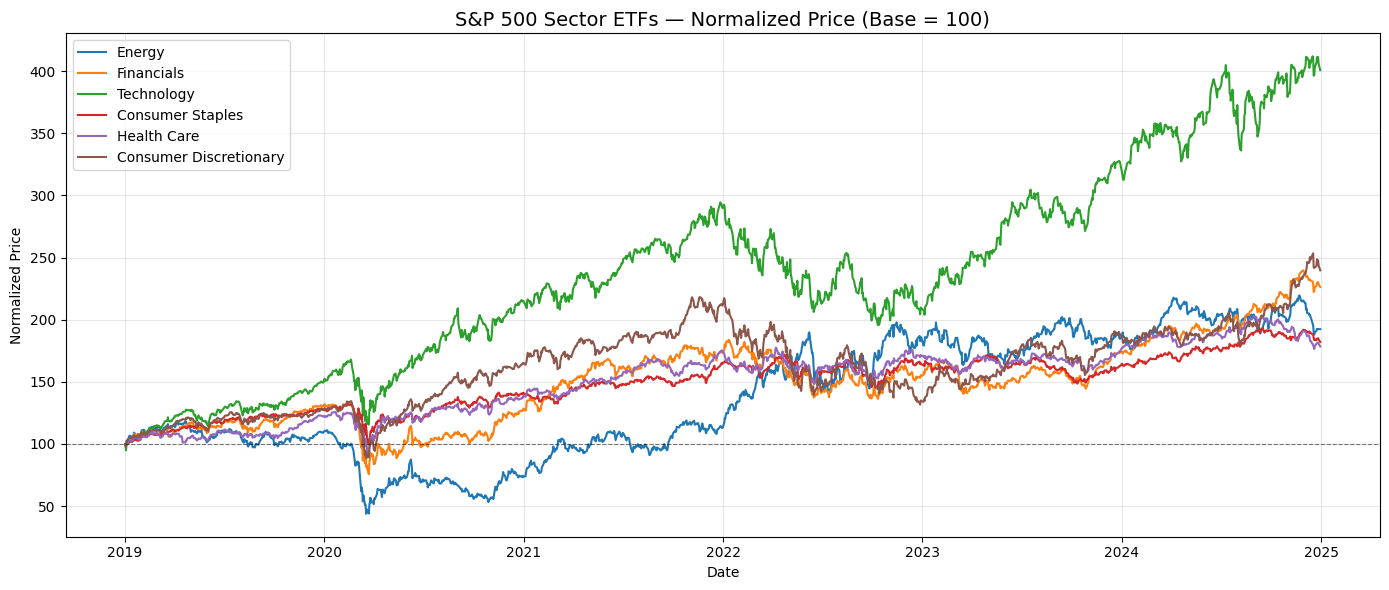

In [9]:
#Plot
fig, ax = plt.subplots(figsize=(14, 6))

for ticker in normalized.columns:
    ax.plot(normalized.index, normalized[ticker], label=SECTOR_NAMES[ticker], linewidth=1.5)

ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('S&P 500 Sector ETFs — Normalized Price (Base = 100)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key observations:** Technology (XLK) was the top-performing sector over the full period (~300% cumulative gain), 
while Energy (XLE) experienced the sharpest drawdown during the COVID crash (dropping below 50). 
Consumer Staples (XLP) showed the most stable trajectory, consistent with its defensive nature. 
Both crisis events — March 2020 and 2022 — are clearly visible across all sectors.

### 3.2 Daily Returns

We compute daily log returns for each sector. Log returns are preferred in financial analysis 
because they are time-additive and better approximate a normal distribution than simple returns.

In [10]:
# Compute daily log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

log_returns.head()

,XLE,XLF,XLK,XLP,XLV,XLY
Date,,,,,,
2019-01-03,-0.009967,-0.022738,-0.051786,-0.005761,-0.020514,-0.021890
2019-01-04,0.033458,0.032680,0.043366,0.021095,0.029395,0.032558
2019-01-07,0.014756,0.001236,0.008903,-0.001366,0.003832,0.022360
2019-01-08,0.007706,0.000823,0.008345,0.009140,0.007734,0.010995
2019-01-09,0.015718,0.004924,0.012863,-0.009335,0.004475,0.005071


### 3.3 Descriptive Statistics of Daily Returns

Summary statistics help identify differences in return distribution across sectors — 
particularly mean return, volatility (std), and tail behavior (skewness, kurtosis).

In [11]:
# Summary statistics
log_returns.describe().round(4)

,XLE,XLF,XLK,XLP,XLV,XLY
count,1508.0000,1508.0000,1508.0000,1508.0000,1508.0000,1508.0000
mean,0.0004,0.0005,0.0009,0.0004,0.0004,0.0006
std,0.0217,0.0157,0.0168,0.0101,0.0111,0.0155
min,-0.2249,-0.1474,-0.1487,-0.0987,-0.1038,-0.1355
25%,-0.0094,-0.0063,-0.0072,-0.0040,-0.0048,-0.0064
50%,0.0009,0.0011,0.0016,0.0007,0.0006,0.0015
75%,0.0108,0.0079,0.0100,0.0054,0.0060,0.0089
max,0.1487,0.1236,0.1109,0.0817,0.0742,0.0897


In [12]:
# Skewness and Kurtosis
skew_kurt = pd.DataFrame({
    'mean': log_returns.mean(),
    'std': log_returns.std(),
    'skewness': log_returns.skew(),
    'kurtosis': log_returns.kurt()
}).round(4)

skew_kurt

,mean,std,skewness,kurtosis
XLE,0.0004,0.0217,-0.9355,14.8389
XLF,0.0005,0.0157,-0.5864,15.3822
XLK,0.0009,0.0168,-0.4552,8.3153
XLP,0.0004,0.0101,-0.4978,17.3737
XLV,0.0004,0.0111,-0.4197,12.1094
XLY,0.0006,0.0155,-0.8009,7.7424


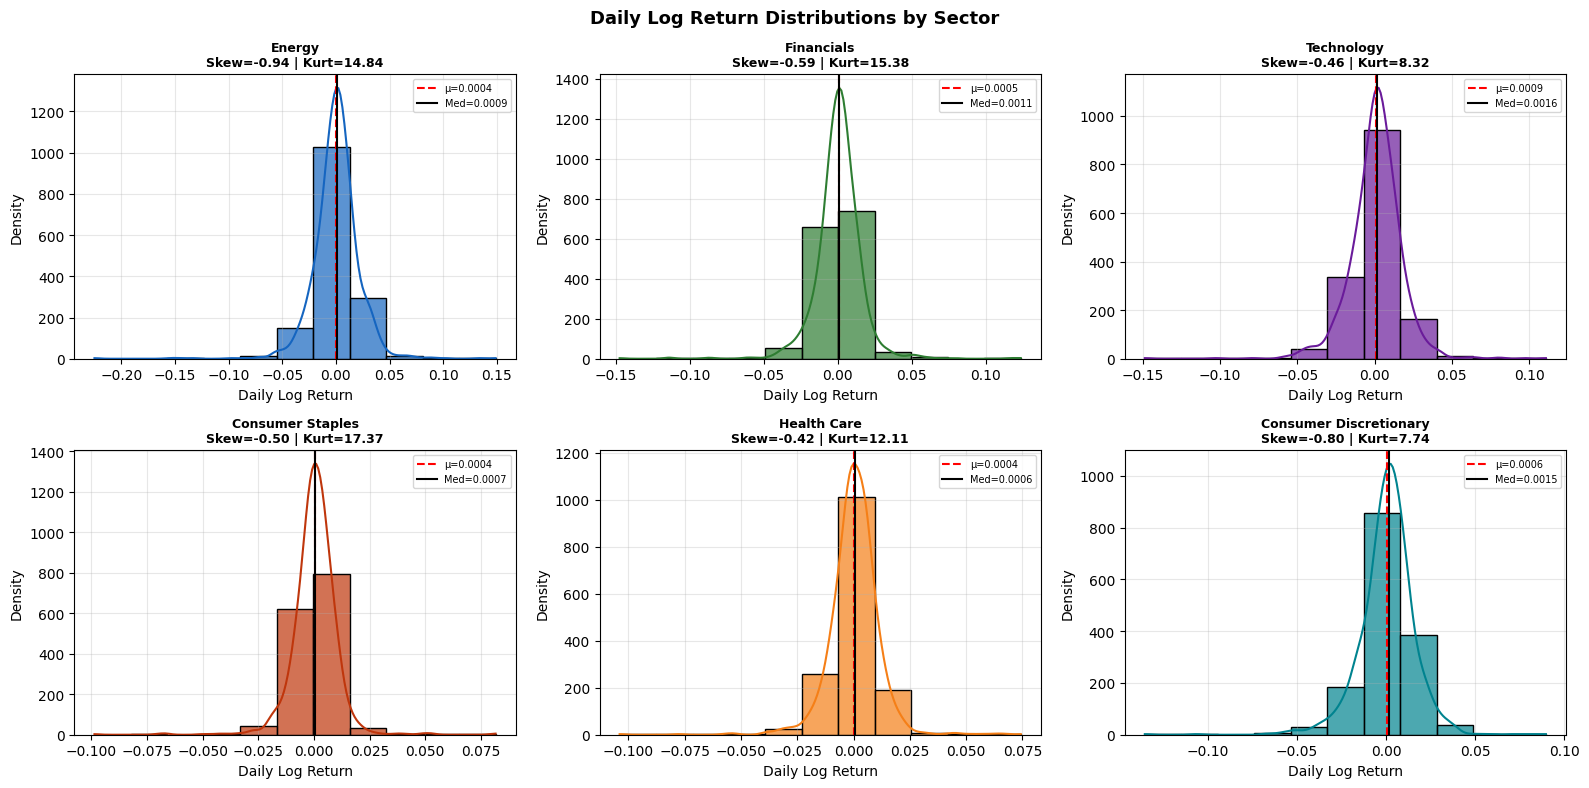

In [13]:
#Plot histograms with KDE
colores = ['#1565C0', '#2E7D32', '#6A1B9A', '#BF360C', '#F57F17', '#00838F']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle('Daily Log Return Distributions by Sector', fontsize=13, fontweight='bold')

for i, (ticker, color) in enumerate(zip(log_returns.columns, colores)):
    s = log_returns[ticker]
    n_bins = int(1 + 3.322 * np.log10(len(s)))

    sns.histplot(s, bins=n_bins, kde=True, ax=axes[i], color=color, alpha=0.7)
    axes[i].axvline(s.mean(),   color='red',   linestyle='--', lw=1.5, label=f'μ={s.mean():.4f}')
    axes[i].axvline(s.median(), color='black', linestyle='-',  lw=1.5, label=f'Med={s.median():.4f}')
    axes[i].set_title(f'{SECTOR_NAMES[ticker]}\nSkew={s.skew():.2f} | Kurt={s.kurtosis():.2f}',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Daily Log Return')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key observations:** Mean returns are close to zero across all sectors, with XLK leading in daily 
average return (0.0009) and XLE showing the highest volatility (std = 0.0217). All sectors exhibit 
negative skewness and excess kurtosis well above 3 — confirming fat tails and a higher-than-expected 
probability of extreme negative returns. XLP is a notable case: lowest volatility, yet highest kurtosis (17.37).

### 3.4 Rolling Volatility

Rolling volatility measures how risk evolved over time for each sector. 
We use a 30-day window of annualized standard deviation of log returns — 
a standard proxy for short-term risk in financial analysis.

We use a 30-day window, the standard short-term convention: long enough to be statistically 
meaningful, short enough to capture rapid market stress. The result is annualized using:

$$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$$

where 252 is the number of trading days in a year — the industry standard for comparing 
volatility across timeframes.

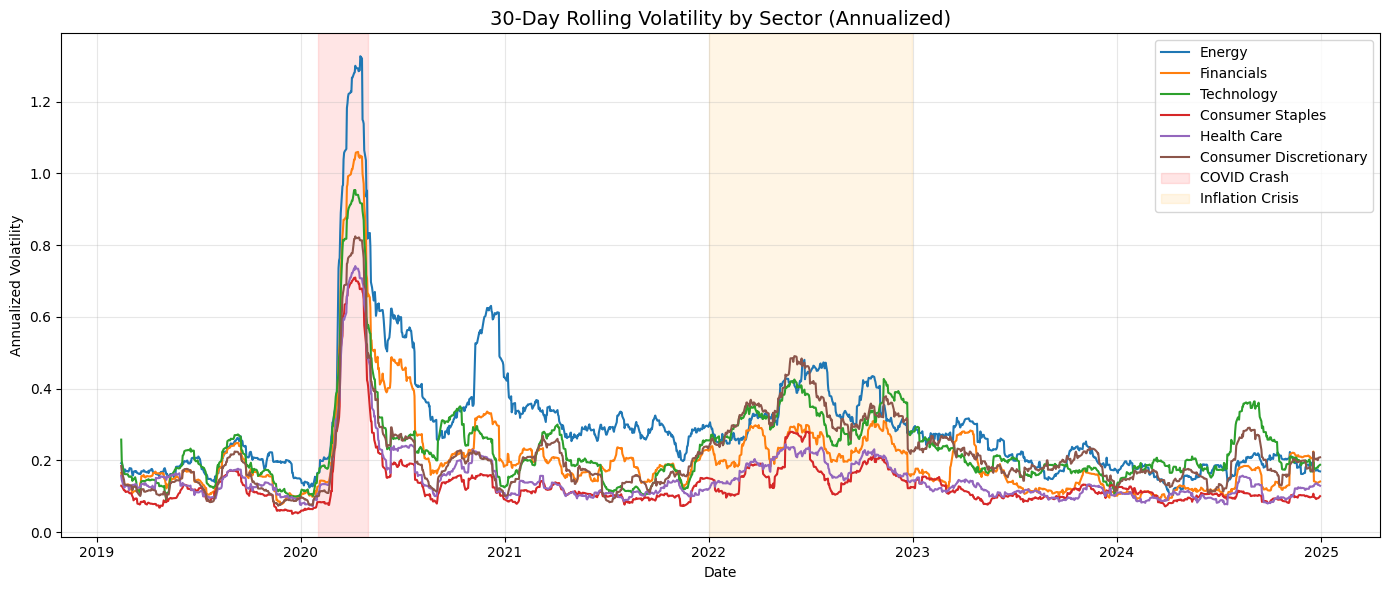

In [14]:
# 30-day rolling volatility, annualized
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 6))

for ticker in rolling_vol.columns:
    ax.plot(rolling_vol.index, rolling_vol[ticker], 
            label=SECTOR_NAMES[ticker], linewidth=1.5)

# Mark crisis periods
ax.axvspan('2020-02-01', '2020-04-30', color='red', alpha=0.1, label='COVID Crash')
ax.axvspan('2022-01-01', '2022-12-31', color='orange', alpha=0.1, label='Inflation Crisis')

ax.set_title('30-Day Rolling Volatility by Sector (Annualized)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key observations:** The COVID crash (March 2020) produced the sharpest volatility spike across 
all sectors, with Energy (XLE) reaching an annualized volatility of ~1.3 — more than double any 
other sector. The 2022 inflationary crisis generated sustained but moderate elevated volatility, 
with no single sector dominating. Consumer Staples (XLP) remained the most stable throughout 
both events, reinforcing its defensive profile. By 2023, volatility normalized across all sectors.